# load things for science :)

In [61]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import matplotlib.pyplot
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.cm
import math
import sys
import csv
import itertools
from scipy import integrate
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path
# from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
# import ipywidgets as widgets
# from ipywidgets import FloatSlider, Layout, HBox, VBox, Label, Output, Button, IntProgress, HTML
from IPython.display import display, clear_output
# %matplotlib widget

In [62]:
## quick check

# import pandas as pd

# csv1 = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_2rec_excl_sp19inb_50nA_local_06_11_2026_smearing.csv")
# csv2 = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_2rec_excl_sp19inb_50nA_local_06_11_2026_NOsmearing.csv")

# # if csv1.shape != csv2.shape:
# #     print("Files have different shapes!")
# #     print(csv1.shape, csv2.shape)
# # else:
# #     differences = csv1.compare(csv2)

# #     print(f"Number of differing cells: {len(differences)}")
# #     print(differences.head())

# #     differences.to_csv("cell_differences.csv")


# # Check shapes first
# print("CSV1 shape:", csv1.shape)
# print("CSV2 shape:", csv2.shape)

# # Rows in csv1 but not csv2
# only_in_csv1 = pd.concat([csv1, csv2]).drop_duplicates(keep=False)

# print(f"\nRows that differ: {len(only_in_csv1)}")
# print(only_in_csv1.head())

# # Save differences
# only_in_csv1.to_csv("csv_differences.csv", index=False)

# PID comparison

In [63]:
# df = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2rec_excl_sp19inb_50nA_jlab_05_29_2026.csv", index_col=False)

# # df.head()

# # Force PID columns to integers
# pid_cols = [
#     "pid_prot_rec", "pid_prot_mc",
#     "pid_pip_rec",  "pid_pip_mc",
#     "pid_pim_rec",  "pid_pim_mc"
# ]

# for col in pid_cols:
#     df[col] = pd.to_numeric(df[col], errors="coerce").astype(int)

# # Mismatch flags
# df["prot_mismatch"] = df["pid_prot_mc"] != df["pid_prot_rec"]
# df["pip_mismatch"]  = df["pid_pip_mc"]  != df["pid_pip_rec"]
# df["pim_mismatch"]  = df["pid_pim_mc"]  != df["pid_pim_rec"]

# # Counts
# print("Total events:", len(df))
# print()

# print("Proton mismatches:", df["prot_mismatch"].sum())
# print("Pi+ mismatches:   ", df["pip_mismatch"].sum())
# print("Pi- mismatches:   ", df["pim_mismatch"].sum())

# # Show problematic rows
# print("\nPi- mismatch examples:")
# print(df[df["pim_mismatch"]][["pid_pim_mc", "pid_pim_rec"]].head(15))

# print("\nProt mismatch examples:")
# print(df[df["prot_mismatch"]][["pid_prot_mc", "pid_prot_rec"]].head(15))

# print("\nPip mismatch examples:")
# print(df[df["pip_mismatch"]][["pid_pip_mc", "pid_pip_rec"]].head(15))

In [64]:
# # Count mismatches per event
# df["num_mismatches"] = (
#     df["prot_mismatch"].astype(int) +
#     df["pip_mismatch"].astype(int) +
#     df["pim_mismatch"].astype(int)
# )

# # Events with multiple mismatches
# multi_mismatch = df[df["num_mismatches"] > 1]

# print("\nEvents with multiple mismatches:", len(multi_mismatch))

# # Breakdown
# print("\nMismatch multiplicity:")
# print(df["num_mismatches"].value_counts().sort_index())

In [65]:
# ###### another quick check

# # df = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2rec_excl_sp19inb_noBG_jlab_05_29_2026.csv", index_col=False)
# # df = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2rec_mPim_sp19inb_50nA_jlab_06_09_2026_2.csv", index_col=False)

# # Force PID columns to integers
# pid_cols = [
#     "pid_prot_rec", "pid_prot_mc",
#     "pid_pip_rec",  "pid_pip_mc",
#     "pid_pim_rec",  "pid_pim_mc"
# ]

# for col in pid_cols:
#     df[col] = pd.to_numeric(df[col], errors="coerce").astype(int)

# # Sequential mismatch logic
# conditions = [
#     df["pid_prot_mc"] != df["pid_prot_rec"],

#     (df["pid_prot_mc"] == df["pid_prot_rec"]) &
#     (df["pid_pip_mc"] != df["pid_pip_rec"]),

#     (df["pid_prot_mc"] == df["pid_prot_rec"]) &
#     (df["pid_pip_mc"] == df["pid_pip_rec"]) &
#     (df["pid_pim_mc"] != df["pid_pim_rec"])
# ]

# choices = [
#     "prot_mismatch",
#     "pip_mismatch",
#     "pim_mismatch"
# ]

# df["match_category"] = np.select(
#     conditions,
#     choices,
#     default="matched"
# )

# # Counts
# print(df["match_category"].value_counts())

# load csv

In [79]:
# change folder name to 'experiment' or 'simulation' or 'threepion_sim'
folder_name = "simulation"

# options are fall18_inb, fall18_outb, spring19_inb, spring19_inb_noBG, spring19_inb_50nA_noSmearing, spring19_inb_50nA,  so far
data_name = "spring19_inb_50nA"

# options include EXCL, mPim, mPip, mProt
topology_name = "EXCL"

# choose a csv file corresponding to the above folder_name
# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/exp/10_6exp_excl_jlab_11_09_2025.csv", index_col=False)

# csv_file = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2rec_excl_sp19inb_50nA_jlab_06_05_2026.csv", index_col=False)
csv_file = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_2rec_excl_sp19inb_50nA_local_06_15_2026_ALLsmearing.csv", index_col=False)
exp_csv = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2exp_excl_sp19inb_pass2_jlab_06_16_2026.csv", index_col=False)

# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2rec_excl_sp19inb_wBG_jlab_04_23_2026.csv", index_col=False)
# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2exp_excl_sp19inb_jlab_04_21_2026_2.csv", index_col=False)
# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2rec_excl_sp19inb_45nA_jlab_04_27_2026.csv", index_col=False)
# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2rec_excl_sp19inb_noBG_jlab_04_27_2026_2.csv", index_col=False)

# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/10_6rec_excl_fa18outb_jlab_2_12_11_2025.csv", index_col=False)
# csv_file = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/testweight/10_6rec_excl_jlab_09_24_2025.csv", index_col=False)
# csv_file = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/testweight/10_6rec_excl_testweight_jlab_12_02_2024.csv", index_col=False)
# csv_file = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/pass2noBG/10_6rec_excl_pass2noBG_jlab_12_02_2024.csv", index_col=False)
# csv_file = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/22GeV/pass2noBG/22rec_excl_pass2noBG_jlab_12_02_2024.csv", index_col=False)

# csv_file = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/twopeg/fall18_inb/10_6rec_excl_fa18inb_jlab_01_16_2026.csv", index_col=False)

# if exp:
# csv_file["weight"] = 1

# read in threepion background csv (for exp and rec bg comparisons)
threepion_csv = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/threepion/10_6rec_excl_3pion_withBG_jlab_07_22_2025.csv", index_col=False)

# base path for future hists
hist_base_path = Path(f'/Users/aosmond/nuclearPhys/notebooks/notebook_hists/{folder_name}/{data_name}/{topology_name}_topology')
csv_base_path = Path(f'/Users/aosmond/nuclearPhys/notebooks/notebook_csvs/{folder_name}/{data_name}/{topology_name}_topology')

In [80]:
csv_file.head()

,event,w,q2,weight,pid_prot_rec,pid_pip_rec,pid_pim_rec,pid_prot_mc,pid_pip_mc,pid_pim_mc,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
0,10,2.358572,4.737334,0.000029,2212,211,-211,2212,211,-211,...,0.218656,100.12760,74.43993,11.808060,12.07894,20.406440,18.22460,25.841340,1.207422,3.647458
1,10,1.541825,4.565415,0.000014,2212,211,-211,2212,211,-211,...,0.098221,28.43483,32.89190,36.980920,48.76389,24.342090,25.72366,4.886386,11.894330,1.385505
2,10,1.957266,5.854790,0.000011,2212,211,-211,2212,211,-211,...,0.278585,23.74254,30.56986,39.951950,52.50549,15.810780,15.92277,8.185584,12.611080,0.204318
3,10,1.368886,6.678289,0.000002,2212,211,-211,2212,211,-211,...,0.101182,26.60611,30.27791,27.339390,30.38165,19.881130,21.34599,8.561306,4.195739,1.974378
4,10,2.290253,3.365631,0.000060,2212,211,-211,211,211,-211,...,1.205053,26.47825,41.68307,9.566934,37.17685,9.514788,39.55258,33.152730,30.953810,30.726030


In [81]:
csv_file.tail()

,event,w,q2,weight,pid_prot_rec,pid_pip_rec,pid_pim_rec,pid_prot_mc,pid_pip_mc,pid_pim_mc,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
1234312,10,2.256637,3.355275,1.760844e-04,2212,211,-211,2212,211,-211,...,0.061005,26.90157,26.05163,19.11068,15.56522,30.31849,31.22321,0.862795,3.852594,1.969312
1234313,10,1.785432,6.380743,1.129240e-05,2212,211,-211,2212,211,-211,...,0.014163,40.85233,40.35673,29.06805,27.89630,16.61850,16.40057,0.751843,1.178678,0.219127
1234314,10,2.138328,5.273110,5.850230e-05,2212,211,-211,2212,211,-211,...,0.074466,34.08877,32.07391,14.41940,13.09741,21.59494,20.15787,2.100093,1.339247,1.610422
1234315,10,1.368040,6.095091,7.710000e-08,2212,211,-211,2212,211,-211,...,0.031682,23.49331,25.23658,23.71524,25.88561,25.50225,25.99573,1.765271,2.173319,0.493482
1234316,10,1.847744,4.038028,5.589790e-05,2212,211,-211,2212,211,-211,...,0.172570,34.62916,30.26906,48.37715,52.37296,20.10818,18.28468,4.376705,11.385740,2.011445


In [82]:
exp_csv.head()

,event,w,q2,weight,pid_prot_rec,pid_pip_rec,pid_pim_rec,pid_prot_mc,pid_pip_mc,pid_pim_mc,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
0,0,2.292130,2.063685,1,2212,211,-211,-999,-999,-999,...,0.025624,46.81455,47.59516,29.58999,30.42093,11.61265,11.51076,0.874471,0.883950,0.126736
1,0,2.393109,2.952282,1,2212,211,-211,-999,-999,-999,...,0.624286,29.77538,33.38359,15.76543,26.25717,20.62925,19.99812,3.769303,14.038250,0.757327
2,0,1.777695,3.722266,1,2212,211,-211,-999,-999,-999,...,0.068191,27.97119,30.03570,59.35152,68.23344,16.32755,17.35928,2.075666,9.107581,1.031775
3,0,1.958665,3.098960,1,2212,211,-211,-999,-999,-999,...,0.037285,47.84676,45.67107,28.86371,28.16679,17.74559,17.69847,2.483378,0.774209,0.362328
4,0,2.304656,2.281736,1,2212,211,-211,-999,-999,-999,...,0.271868,29.45446,38.39880,16.55388,17.93248,27.71925,32.74365,9.161918,1.397170,5.031284


In [83]:
exp_csv.tail()

,event,w,q2,weight,pid_prot_rec,pid_pip_rec,pid_pim_rec,pid_prot_mc,pid_pip_mc,pid_pim_mc,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
6070641,0,1.918260,2.046328,1,2212,211,-211,-999,-999,-999,...,0.017180,33.42455,33.02933,52.69969,49.58324,11.36781,10.55049,0.515883,3.170338,0.820246
6070642,0,1.832414,2.883022,1,2212,211,-211,-999,-999,-999,...,0.037733,40.11202,39.11223,17.53612,15.97284,24.02966,23.47047,1.441017,1.675226,1.397674
6070643,0,2.195808,3.205842,1,2212,211,-211,-999,-999,-999,...,0.823326,16.16187,71.81316,12.08804,23.48224,15.18740,23.05700,56.184540,11.458830,7.870580
6070644,0,2.338025,2.684567,1,2212,211,-211,-999,-999,-999,...,0.019677,18.49548,18.17933,12.60047,11.86118,44.85457,43.36672,0.471936,0.829090,1.536167
6070645,0,2.474596,4.080697,1,2212,211,-211,-999,-999,-999,...,3.112647,17.44542,62.33084,21.62986,18.11765,19.34894,12.07485,74.815410,4.593458,12.975730


In [84]:
w_min = csv_file["w"].min()
w_max = csv_file["w"].max()

q2_min = csv_file["q2"].min()
q2_max = csv_file["q2"].max()

print("w min:", w_min)
print("w max:", w_max)
print("q2 min:", q2_min)
print("q2 max:", q2_max)


w min: 1.000222
w max: 2.5
q2 min: 1.453741
q2 max: 11.99919


In [85]:
bins_value = 100
step = 0.001

# --- Define MM² ranges for each topology ---
topologies = {
    "excl": (-0.03, 0.03),
    "mProt": (-0.1, 2.5),
    "mPip": (-0.4, 0.6),
    "mPim": (-0.4, 0.6),
}

# determine mismatches

In [86]:
# Force PID columns to integers
pid_cols = [
    "pid_prot_rec", "pid_prot_mc",
    "pid_pip_rec",  "pid_pip_mc",
    "pid_pim_rec",  "pid_pim_mc"
]

for col in pid_cols:
    csv_file[col] = pd.to_numeric(csv_file[col], errors="coerce").astype(int)

# Sequential mismatch logic
conditions = [
    csv_file["pid_prot_mc"] != csv_file["pid_prot_rec"],

    (csv_file["pid_prot_mc"] == csv_file["pid_prot_rec"]) &
    (csv_file["pid_pip_mc"] != csv_file["pid_pip_rec"]),

    (csv_file["pid_prot_mc"] == csv_file["pid_prot_rec"]) &
    (csv_file["pid_pip_mc"] == csv_file["pid_pip_rec"]) &
    (csv_file["pid_pim_mc"] != csv_file["pid_pim_rec"])
]

choices = [
    "prot_mismatch",
    "pip_mismatch",
    "pim_mismatch"
]

csv_file["match_category"] = np.select(
    conditions,
    choices,
    default="matched"
)

# Counts
print(csv_file["match_category"].value_counts())

match_category
matched          1208944
pip_mismatch       15201
pim_mismatch        6704
prot_mismatch       3468
Name: count, dtype: int64


# w-q2 range

In [87]:
# w and q2 ranges
w_bins = np.append(np.arange(1.4, 2.5, 0.05), 2.5)
q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0] #,13.0] ## original range was 8,9,11,13 but I added finer binning (?)
# q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0] 

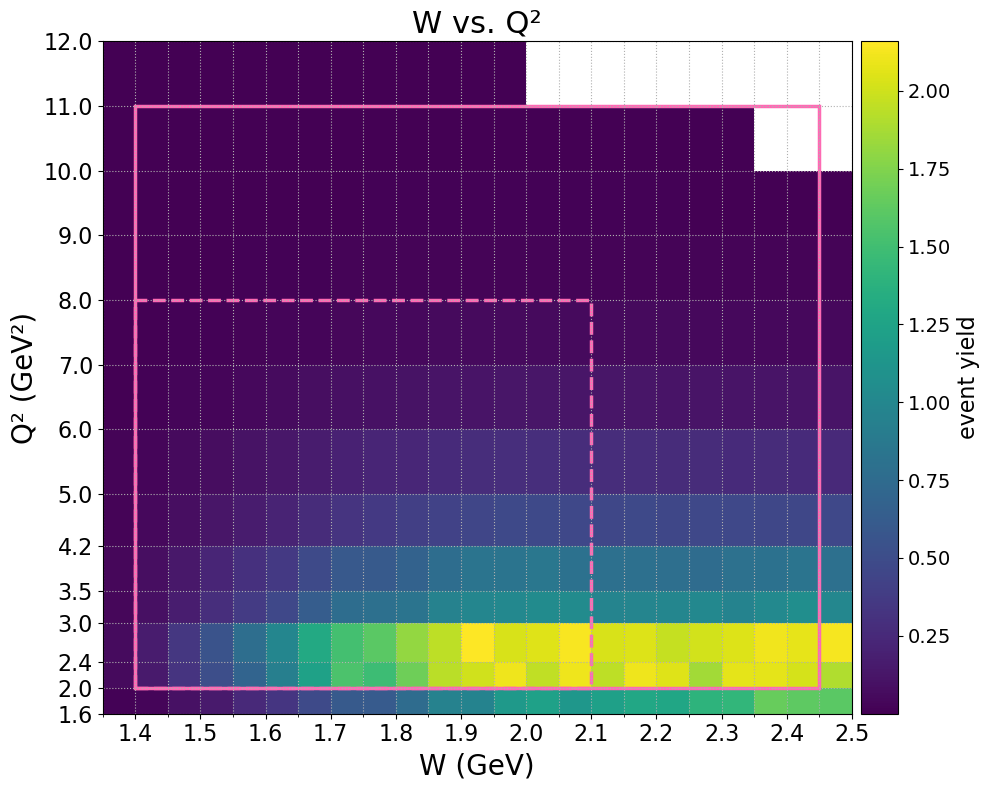

In [88]:
# Define which dataset to visualize
# dataset = csv_file 
# dataset = threepion_csv\
# dataset = df

w_range = np.append(np.arange(1.35, 2.5, 0.05), 2.5)
q2_range = [1.6,2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0] #,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0]

###### fine bins
n_w_bins  = 300  #500
n_q2_bins = 300

w_min, w_max   = 1.35, 2.50
q2_min, q2_max = 1.6, 12.0

# --- W vs Q² histograms with colorbars for each topology ---
# Define bin edges from your ranges
bin_x = w_range
bin_y = q2_range

# for topo in topologies:
fig, ax = plt.subplots(figsize=(10, 8))
mask = csv_file["w"].notna() & csv_file["q2"].notna()
w_vals = csv_file.loc[mask, "w"].to_numpy()
q2_vals = csv_file.loc[mask, "q2"].to_numpy()
weights = csv_file.loc[mask, "weight"].to_numpy()

# 2D histogram — color represents event density
h = ax.hist2d(w_vals, q2_vals, bins=[bin_x, bin_y], cmap='viridis', cmin=1e-12, weights=weights, density=False)

# Title and axes
ax.set_title(f"W vs. Q²", fontsize=22)
ax.set_xlabel("W (GeV)", fontsize=20)
ax.set_ylabel("Q² (GeV²)", fontsize=20)

# Colorbar setup
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
cb = plt.colorbar(h[3], cax=cax)
cb.set_label("event yield", fontsize=16)
cb.ax.tick_params(labelsize=14)

# Grid and ticks
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xticks(np.append(np.arange(1.4, 2.5, 0.1), 2.5))
ax.set_xticks(bin_x, minor=True) 
ax.set_yticks(bin_y)

# Define analyzed range
w_min_analyzed, w_max_analyzed = 1.4, 2.45
q2_min_analyzed, q2_max_analyzed = 2.0, 11.0

# Create a red rectangle
rect = patches.Rectangle(
    (w_min_analyzed, q2_min_analyzed),  # bottom-left corner
    w_max_analyzed - w_min_analyzed,    # width
    q2_max_analyzed - q2_min_analyzed,  # height
    linewidth=2.5, edgecolor='hotpink', alpha=1.0, facecolor='none')

# Define analyzed range
w_min_analyzed_krishna, w_max_analyzed_krishna = 1.4, 2.10
q2_min_analyzed_krishna, q2_max_analyzed_krishna = 2.0, 8.0

# Create a red rectangle
rect_krishna = patches.Rectangle(
    (w_min_analyzed_krishna, q2_min_analyzed_krishna),  # bottom-left corner
    w_max_analyzed_krishna - w_min_analyzed_krishna,    # width
    q2_max_analyzed_krishna - q2_min_analyzed_krishna,  # height
    linewidth=2.5, edgecolor='hotpink', alpha=1.0, linestyle='--', facecolor='none')

# Add rectangle to the axes
ax.add_patch(rect)
ax.add_patch(rect_krishna)

plt.tight_layout()
plt.show()

# w-q2 binned cuts

In [89]:
# w and q2 ranges
w_bins = np.append(np.arange(1.4, 2.5, 0.05), 2.5)
q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0] #,13.0]

In [90]:
# --- Initialize cut_results for all systematic cuts ---
cut_results = {
    "mm2": {"in": {}, "out": {}, "all": {}},
    "theta": {"in": {}, "out": {}, "all": {}},
    "momentum": {"in": {}, "out": {}, "all": {}}
}

# mm2 misID

In [91]:
binned_hist_path = Path("MM2_binned_wq2/mm2_misID")

# --- Gaussian function ---
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# --- Define MM² topologies ---
topologies_mm2 = {
    # "excl":  {"range": (-0.03, 0.03), "fit_window": (-0.02, 0.02)},
    # "mProt": {"range": (-0.1, 2.5),   "fit_window": (0.4, 1.25)},
    # "mPip":  {"range": (-0.4, 0.6),   "fit_window": (-0.3, 0.2)},
    # "mPim":  {"range": (-0.4, 0.6),   "fit_window": (-0.3, 0.2)},
    "excl":  {"range": (-0.03, 0.03), "fit_window": (-0.02, 0.02)},
    "mProt": {"range": (-0.1, 2.5),   "fit_window": (0.4, 1.25)},
    "mPip":  {"range": (-0.3, 0.3),   "fit_window": (-0.3, 0.3)},
    # "mPim":  {"range": (-0.3, 0.3),   "fit_window": (-0.1, 0.15)},
    "mPim":  {"range": (-0.3, 0.3),   "fit_window": (-0.3, 0.3)},
}

# ==========================================
# Choose which events to plot
# ==========================================

# options: mismatch, matched, all
plot_type = "all"

if plot_type == "mismatch":
    csv_file = csv_file[csv_file["match_category"] != "matched"].copy()

elif plot_type == "matched":
    csv_file = csv_file[csv_file["match_category"] == "matched"].copy()

elif plot_type == "all":
    csv_file = csv_file.copy()

else:
    raise ValueError(f"Unknown plot_type: {plot_type}")

print(f"\nPlot type: {plot_type}")
print(f"Events used: {len(csv_file)}")

csv_file['w_bin'] = pd.cut(csv_file['w'], bins=w_bins, labels=False, right=False)
csv_file['q2_bin'] = pd.cut(csv_file['q2'], bins=q2_bins, labels=False, right=False)
binned_data = csv_file.dropna(subset=['w_bin', 'q2_bin'])

exp_csv['w_bin'] = pd.cut(exp_csv['w'], bins=w_bins, labels=False, right=False)
exp_csv['q2_bin'] = pd.cut(exp_csv['q2'], bins=q2_bins, labels=False, right=False)
exp_binned_data = exp_csv.dropna(subset=['w_bin', 'q2_bin'])

# --- Helpers ---
def bin_label(bin_idx, bin_edges):
    if bin_idx < len(bin_edges) - 1:
        return f"[{bin_edges[bin_idx]:.2f}, {bin_edges[bin_idx + 1]:.2f})"
    return "[out of range)"

def safe_str(label):
    return label.strip("[]()").replace(",", "_").replace(" ", "")

# sigma_factors = np.arange(0.5, 1.75 + 0.001, 0.25)
sigma_factors = [0.5, 1.5, 1.75, 2.0]
cmap = plt.cm.rainbow_r
sigma_colors = cmap(np.linspace(0, 1, len(sigma_factors)))

# --- Process a single (W,Q2) bin ---
def process_bin(group, w_bin, q2_bin, topo, sigma=1.1775):
    """Process a single (w,q2) bin with Gaussian fit cuts for a given MM² topology."""
    w_label = bin_label(w_bin, w_bins)
    q2_label = bin_label(q2_bin, q2_bins)
    column = f"mm2_{topo}"
    x_min, x_max = topologies_mm2[topo]["range"]

    # Histogram over plotting range
    values, bins = np.histogram(group[column].dropna(), bins=bins_value, range=(x_min, x_max))
    bin_centers = (bins[:-1] + bins[1:]) / 2.0

    # initialize fit & cut results
    amp_fit = mean_fit = sigma_fit = None
    left_out = right_out = left_in = right_in = None

    all_group = group.copy()
    mismatch_group = group[group["match_category"] != "matched"]
    matched_group = group[group["match_category"] == "matched"]

    n_all = len(all_group)
    n_mismatch = len(mismatch_group)
    n_matched = len(matched_group)

    exp_group = exp_binned_data[
        (exp_binned_data["w_bin"] == w_bin) &
        (exp_binned_data["q2_bin"] == q2_bin)
    ]

    n_exp = len(exp_group)

    try:
        # --- get user-provided fit window (must be tuple (left, right)) ---
        fit_window = topologies_mm2[topo].get("fit_window", None)
        if fit_window is None:
            raise ValueError(f"No fit_window defined for topology '{topo}'")

        if not (isinstance(fit_window, tuple) and len(fit_window) == 2):
            raise ValueError(f"fit_window for '{topo}' must be a tuple (left, right)")

        fit_window_left, fit_window_right = fit_window

        # --- Restrict fit mask to the intersection of fit_window and plotting range ---
        fit_mask = (bin_centers >= fit_window_left) & (bin_centers <= fit_window_right)

        # If there are no bins inside the fit window, expand to nearest valid bins inside plotting range
        if not np.any(fit_mask):
            # find bins inside plotting range and attempt small fallback (use full plotting range)
            fit_mask = (bin_centers >= x_min) & (bin_centers <= x_max)
            if not np.any(fit_mask):
                raise ValueError("No histogram bins in plotting range to fit.")

        # --- Find peak inside fit window (local peak) ---
        local_values = values[fit_mask]
        local_centers = bin_centers[fit_mask]

        # If all zeros, raise to fallback
        if local_values.sum() == 0:
            raise ValueError("No counts in fit window to determine peak.")

        local_peak_idx = np.argmax(local_values)
        # convert local index back to global index in bin_centers
        global_peak_idx = np.where(fit_mask)[0][local_peak_idx]
        peak_x = bin_centers[global_peak_idx]

        # --- Prepare fit arrays (only inside fit window) ---
        x_fit = local_centers
        y_fit = local_values

        # require at least 3 points to fit a Gaussian robustly
        if len(x_fit) < 3 or y_fit.sum() == 0:
            raise ValueError("Insufficient points in fit window for Gaussian fit.")

        # initial guesses
        amp_guess = float(y_fit.max())
        mean_guess = float(peak_x)
        sigma_guess = max(1e-6, 0.25 * (fit_window_right - fit_window_left))  # avoid zero

        # --- Fit Gaussian only on the fit window data ---
        popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[amp_guess, mean_guess, sigma_guess], maxfev=20000)
        amp_fit, mean_fit, sigma_fit = popt

        for i, sigma in enumerate(sigma_factors):
            left  = mean_fit - sigma * sigma_fit
            right = mean_fit + sigma * sigma_fit

            inside_df = group[group[column].between(left, right)]
            outside_df = group[~group[column].between(left, right)]

            cut_results.setdefault("mm2", {}).setdefault("in", {})[(w_bin, q2_bin, topo, sigma)] = inside_df
            cut_results.setdefault("mm2", {}).setdefault("out", {})[(w_bin, q2_bin, topo, sigma)] = outside_df

        all_df = group.copy()
        cut_results.setdefault("mm2", {}).setdefault("all", {})[(w_bin, q2_bin, topo)] = all_df

    except Exception as e:
        print(f"Skipping bad bin -> {topo}, W-bin {w_bin}, Q2-bin {q2_bin}: {e}")
        return

    sim_vals = all_group[column].dropna()
    exp_vals = exp_group[column].dropna()

    # only count events inside plotting range
    sim_in_range = sim_vals[
        (sim_vals >= x_min) &
        (sim_vals <= x_max)
    ]

    exp_in_range = exp_vals[
        # (exp_vals >= x_min) &
        # (exp_vals <= x_max)
        (exp_vals >= fit_window_left) &
        (exp_vals <= fit_window_right)
    ]

    sim_integral = len(sim_in_range)
    exp_integral = len(exp_in_range)

    if exp_integral > 0:
        exp_scale = sim_integral / exp_integral
    else:
        exp_scale = 1.0

    # --- Plot results ---
    plt.figure(figsize=(11, 7))
    # plt.hist(group[column].dropna(), bins=bins_value, range=(x_min, x_max), label="all events", alpha=0.8, color='black', histtype='step', linewidth=0.8)
    
    # --- ALL EVENTS ---
    plt.hist(
        all_group[column].dropna(),
        bins=bins_value,
        range=(x_min, x_max),
        histtype='step',
        linewidth=1.0,
        color='black',
        label=f"all events (N={n_all})"
    )

    # --- MISMATCH EVENTS ---
    plt.hist(
        mismatch_group[column].dropna(),
        bins=bins_value,
        range=(x_min, x_max),
        histtype='step',
        linewidth=1.0,
        linestyle='--',
        color='red',
        label=f"mismatches (N={n_mismatch})"
    )

    # --- MATCHED EVENTS ---
    plt.hist(
        matched_group[column].dropna(),
        bins=bins_value,
        range=(x_min, x_max),
        histtype='step',
        linewidth=1.0,
        linestyle='--',
        color='green',
        label=f"matches (N={n_matched})"
    )

    # --- EXPERIMENT (scaled to simulation integral) ---
    if len(exp_vals) > 0:

        plt.hist(
            exp_vals,
            bins=bins_value,
            range=(x_min, x_max),
            histtype='step',
            linewidth=1.0,
            linestyle='--',
            color='blue',
            weights=np.ones(len(exp_vals)) * exp_scale,
            label=f"exp scaled (N={n_exp}, scale={exp_scale:.2f})"
        )

    # --- Plot multiple in-cuts ---
    for i, sigma in enumerate(sigma_factors):
        left = mean_fit - sigma * sigma_fit
        right = mean_fit + sigma * sigma_fit

        color = sigma_colors[i]
        lw = 1.2
        alpha = 0.9

    # Title & labels
    plt.title(f"{topo} MM²: W {w_label}, Q² {q2_label}", fontsize=25)
    plt.xlabel('MM² [GeV²]', fontsize=20)
    plt.xlim(x_min, x_max)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(alpha=0.5)
    plt.legend(fontsize=12, loc='upper right')

    # Save figure
    outdir = hist_base_path / binned_hist_path / f"mm2cuts_{topo}_{plot_type}"
    outdir.mkdir(parents=True, exist_ok=True)
    fname = outdir / f"mm2_W_{safe_str(w_label)}_Q2_{safe_str(q2_label)}.png"
    plt.savefig(fname, dpi=300)
    plt.close()

# --- Main loop over MM² topologies ---
for topo in topologies_mm2:
    total_bins = binned_data.groupby(['w_bin', 'q2_bin']).ngroups
    for i, ((w_bin, q2_bin), group) in enumerate(binned_data.groupby(['w_bin', 'q2_bin']), start=1):
        process_bin(group, int(w_bin), int(q2_bin), topo, sigma=3.0)
        print(f"{topo}: Saved histogram {i}/{total_bins} ({i/total_bins*100:.2f}% complete)", end="\r")
        sys.stdout.flush()
    print()  # new line after each topo


Plot type: all
Events used: 1234317
excl: Saved histogram 239/239 (100.00% complete)
mProt: Saved histogram 239/239 (100.00% complete)
mPip: Saved histogram 239/239 (100.00% complete)
mPim: Saved histogram 239/239 (100.00% complete)
